## Introduction<a id='introduction'></a>

**Purpose:**

Train RNN.

**Context:**

&emsp; Pickleball is an addictively fun racquet sport combining aspects of tennis, table tennis, and badminton and pickleball players are similarly diverse with players of all ages and all sports backgrounds. Players often spend hours on the courts both playing and socializing between games. A common topic of discussion amongst players is strategy with questions such as

* "Should I be dropping or driving my third shots?"
* "What kind of shots are more common at higher levels of play?"

This project aims to answer common questions in pickleball using data from pklmart.

**Data:**

Collection of pklmart data on Kaggle (https://www.kaggle.com/datasets/cakesofspan/pklmarts-competitive-pickleball-extracts). \
Pklmart (https://pklmart.com/) \
Tutorial for time series forecasting using TensorFlow (https://www.tensorflow.org/tutorials/structured_data/time_series)

**Outcomes from this notebook (Training):**

**Outcomes from previous notebook (Preprocessing):**


## Approach

**Goal:**
- Recommend shot type and location of third shot by forecasting pickleball rally using a recurrent neural network conditioned on serve, return, and shot type and location of third shot.

**ML Approach:**
- Using a standard RNN or LSTM model, predict details of the next shot using information about the previous 2 shots. After making prediction, feed output back into to the model to make another prediction until model spits out a token indicating the end of a rally.
    - This would be an autoregressive approach where we are using 2 time-series inputs to predict 1 time step ahead. We would also be forecast for all features.

**Architecture Details:**
- Data are structured as windows of consecutive samples.
    - Main features of input windows (should be input_width=2) are
        - The width (the number of time steps) of the input and label windows
        - The time offset between them (offset=1)
        - Which features are used as inputs, labels, or both. In this case, all features are used as inputs and labels
    - Data are handled using a WindowGenerator class

**Data Details:**
- Data are 3 dimensional with (rally, shot, features) as the dimensions
    - Features include x, y positions, shot angle, shot distance, shot type


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Andy's path to project data folder
data_path = '/content/drive/MyDrive/Colab Notebooks/DSCI 521 Final Project (Pickleball Analytics)/data/'

# tutorial dataset
csv_path = data_path+'testing/jena_climate_2009_2016.csv'

df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

### Cleaning and Preparing Testing Dataset from Tutorial

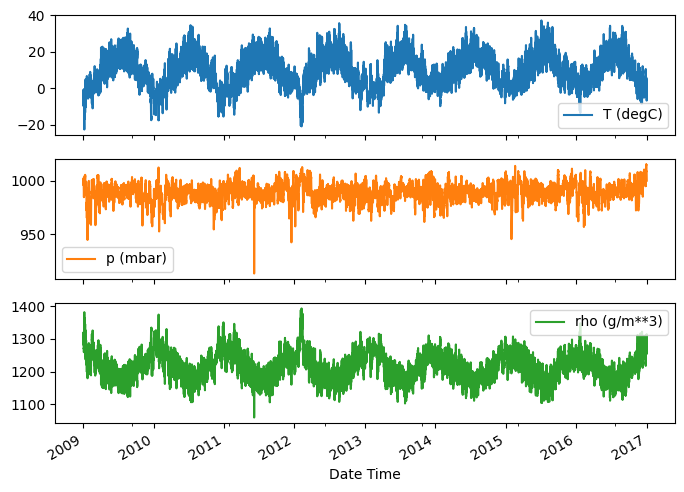

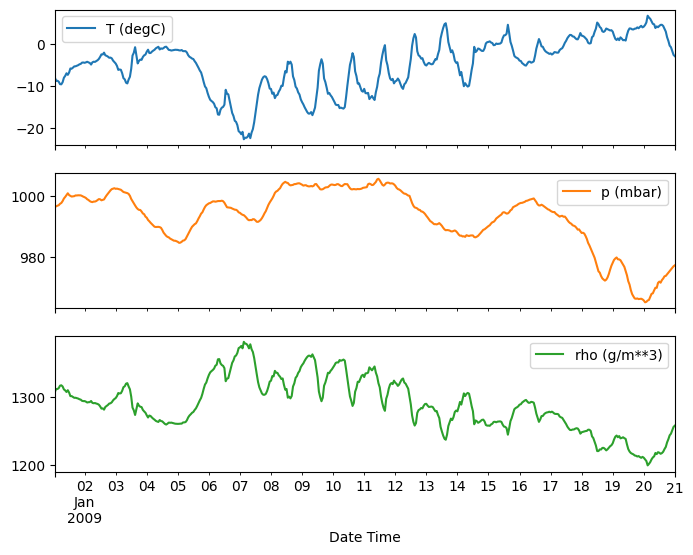

In [ ]:
plot_cols = ['T (degC)', 'p (mbar)', 'rho (g/m**3)']
plot_features = df[plot_cols]
plot_features.index = date_time
_ = plot_features.plot(subplots=True)

plot_features = df[plot_cols][:480]
plot_features.index = date_time[:480]
_ = plot_features.plot(subplots=True)

In [ ]:
wv = df['wv (m/s)']
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df['max. wv (m/s)']
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

In [ ]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

# Convert to radians.
wd_rad = df.pop('wd (deg)')*np.pi / 180

# Calculate the wind x and y components.
df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

# Calculate the max wind x and y components.
df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

In [ ]:
timestamp_s = date_time.map(pd.Timestamp.timestamp)

In [ ]:
# extracting train, val, test with (70, 20, 10) split then normalizing
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

num_features = df.shape[1]

train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

In [ ]:
train_df

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy
5,0.945308,-1.982473,-2.041888,-1.918973,1.117102,-1.302851,-1.477323,-0.790424,-1.480036,-1.482697,2.218524,0.193409,0.221161,0.111140,0.217928
11,0.959770,-2.078372,-2.138166,-2.060964,1.044617,-1.330143,-1.534354,-0.786272,-1.536190,-1.539035,2.325708,0.172987,0.222101,0.109458,0.227798
17,0.986284,-2.070284,-2.132435,-2.045187,1.062738,-1.328843,-1.527225,-0.788348,-1.528703,-1.531992,2.323998,0.207983,0.276266,0.111218,0.324078
23,1.004362,-2.098014,-2.161090,-2.096820,1.008375,-1.336641,-1.546235,-0.782121,-1.547420,-1.553119,2.358913,0.270343,0.195267,0.246907,0.145176
29,1.061006,-2.165028,-2.232152,-2.187178,0.984214,-1.353535,-1.579503,-0.782121,-1.581113,-1.585982,2.446320,0.112264,0.350818,0.048640,0.402053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
294353,0.169167,0.904892,0.886564,1.571997,0.947972,0.776492,1.984916,-0.493604,1.979016,1.977352,-0.882480,-0.166720,-1.508412,-0.155728,-1.363530
294359,0.266787,0.879473,0.853325,1.405624,0.621793,0.742703,1.680752,-0.283962,1.672043,1.672192,-0.822662,-0.824901,-0.641039,-0.704391,-0.475387
294365,0.217374,0.740824,0.719224,1.425703,1.086900,0.559461,1.716396,-0.605690,1.709479,1.707403,-0.716211,-0.030746,0.645277,0.013960,0.600050
294371,0.213759,0.710783,0.689423,1.412795,1.147303,0.521772,1.692633,-0.645127,1.687018,1.683929,-0.689842,0.014300,-0.102616,-0.095117,-0.198426


### Loading Pickleball Data

In [ ]:
pb_df = pd.read_csv(data_path+'processed/clean_mdl_data.csv', index_col=0)
pb_df.rename(columns={'final_shot_type':'shot_type'}, inplace=True)
pb_df.head(2)

,rally_id,rally_nbr,rally_len,shot_nbr,loc_x,loc_y,next_loc_x,next_loc_y,delta_x_loc,delta_y_loc,shot_distance,shot_angle,srv_point_won,skill_lvl,team_hitting,missing_value_flag,shot_type
0,R814,1,5,1,0.6055,-1.2915,0.0665,1.3175,-0.539,2.6090,2.664095,1.774523,0,Pro,1,0,Serve
1,R814,1,5,2,0.0665,1.3175,0.6455,-1.2620,0.579,-2.5795,2.643683,-1.349994,0,Pro,0,0,Return


In [ ]:
pb_df.columns

Index(['rally_id', 'rally_nbr', 'rally_len', 'shot_nbr', 'loc_x', 'loc_y',
       'next_loc_x', 'next_loc_y', 'delta_x_loc', 'delta_y_loc',
       'shot_distance', 'shot_angle', 'srv_point_won', 'skill_lvl',
       'team_hitting', 'missing_value_flag', 'shot_type'],
      dtype='object')

In [ ]:
def get_shots(df: pd.DataFrame, rally_id: str, length: int, feature_cols: list) -> np.array:
    '''
    For given rally_id, pulls all shot data where features are provided in feature_cols
    Shot data are returned with standard length determined by length param

    Will return None if rally length for rally_id is greater than length
    Will pad if rally length is less than length

    Inputs:
        df - master dataframe to pull data from; pd.DataFrame
        rally_id - identifier for rally; str
        length - standard length of rally; int
        feature_cols - list of columns to pull; list
    Returns:
        shots - shot information for rally; np.array([1, length, len(feature_cols])
    '''
    my_df = df.loc[df['rally_id'] == rally_id, feature_cols]

    rally_length = len(my_df)
    if rally_length > length:
        print('Rally length is greater than standard length. Increase length or exclude rally_id')
        print(f'Rally id: {rally_id}; rally_len: {len(my_df)}')
        return None

    if rally_length < length:
        n_repeats = length-rally_length

        last_row = my_df.iloc[-1:]
        repeated_rows = pd.concat([last_row] * n_repeats, ignore_index=True)
        my_df = pd.concat([my_df, repeated_rows], ignore_index=True)

    return my_df.values.reshape(1, length, len(feature_cols))

In [ ]:
def gen_X(df: pd.DataFrame, skill_lvls: list, length: int, feature_cols: list) -> np.array:
    '''
    Creates X for training by pulling data from df
    Inputs:
        df - master dataframe to pull data from; pd.DataFrame
        skill_lvls - list of skill levels to pull for; list
        length - standard length of rally; int
        feature_cols - list of columns to pull; list
    Returns:
        X - tensor in shape of (len(rally_ids), length, len(feature_cols)); np.array
    '''
    # filter by skill level
    skill_mask = [True if x in skill_lvls else False for x in df['skill_lvl']]
    my_df = df[skill_mask]

    # filter by rally length
    rally_len_mask = [True if r_len <= length else False for r_len in my_df['rally_len']]
    my_df = my_df[rally_len_mask]

    rally_ids = my_df['rally_id'].unique()

    # extract and form into tensor
    X = np.zeros([len(rally_ids), length, len(feature_cols)])
    for i, r_id in enumerate(rally_ids):
        shots = get_shots(my_df, r_id, length, feature_cols)

        X[i] = shots

    return X

In [ ]:
pb_df.columns

Index(['rally_id', 'rally_nbr', 'rally_len', 'shot_nbr', 'loc_x', 'loc_y',
       'next_loc_x', 'next_loc_y', 'delta_x_loc', 'delta_y_loc',
       'shot_distance', 'shot_angle', 'srv_point_won', 'skill_lvl',
       'team_hitting', 'missing_value_flag', 'shot_type'],
      dtype='object')

In [ ]:
feature_cols = ['loc_x', 'loc_y', 'next_loc_x', 'next_loc_y', 'delta_x_loc',
                'delta_y_loc', 'shot_distance', 'shot_angle', 'missing_value_flag']
X_40 = gen_X(pb_df, ['4.0'], 30, feature_cols)

In [ ]:
np.save(data_path+'/testing/X_40.npy', X_40)

### Implementing WindowGenerator class and applying to train, val, test

In [ ]:
# test if this WindowGenerator class works with data
# `WindowGenerator` returns all features as labels
# if you don't set the `label_columns` argument
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                train_df=train_df, val_df=val_df, test_df=test_df,
                label_columns=None):
        # Store the raw data.
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Work out the label column indices.
        # Will work when label_columns == None but not sure it will otherwise
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in
                                        enumerate(label_columns)}
        self.column_indices = {name: i for i, name in
                                enumerate(train_df.columns)}

        # Work out the window parameters.
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

    # gets called in make_dataset, may need to modify
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1)

        # Slicing doesn't preserve static shape information, so set the shapes
        # manually. This way the `tf.data.Datasets` are easier to inspect.
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels

    # need to modify this to operate with tensor shaped data
    # may need to call timeseries_dataset_from_array for each rally
    # data called should be in form of (batch_size, length, len(feature_cols))
    def make_dataset(self, data, batch_size=32):
        data = np.array(data, dtype=np.float32)
        # timeseries_dataset_from_array expects array
        # look into tf.data.Dataset.from_tensor_slices
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=batch_size,)

        ds = ds.map(self.split_window)

        return ds

    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def example(self):
        """Get and cache an example batch of `inputs, labels` for plotting."""
        result = getattr(self, '_example', None)
        if result is None:
            # No example batch was found, so get one from the `.train` dataset
            result = next(iter(self.train))
            # And cache it for next time
            self._example = result
        return result

    def plot(self, model=None, plot_col='T (degC)', max_subplots=3):
        inputs, labels = self.example
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                    label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_indices.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_indices, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)

            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()

        plt.xlabel('Time [h]')

        return

In [ ]:
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['T (degC)'])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['T (degC)']

In [ ]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 15)
Inputs shape: (3, 6, 15)
Labels shape: (3, 1, 1)


In [ ]:
example_window.

TensorShape([3, 7, 15])

In [ ]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 15), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [ ]:
# Iterating over a Dataset yields concrete batches
for example_inputs, example_labels in w2.train.take(1):
  print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
  print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 15)
Labels shape (batch, time, features): (32, 1, 1)


### Baseline Model

Mostly used to reproduce tutorial, may not be needed for our data

In [ ]:
single_step_window = WindowGenerator(
    input_width=1, label_width=1, shift=1,
    label_columns=['T (degC)'])
single_step_window

Total window size: 2
Input indices: [0]
Label indices: [1]
Label column name(s): ['T (degC)']

In [ ]:
class Baseline(tf.keras.Model):
  def __init__(self, label_index=None):
    super().__init__()
    self.label_index = label_index

  def call(self, inputs):
    if self.label_index is None:
      return inputs
    result = inputs[:, :, self.label_index]
    return result[:, :, tf.newaxis]

In [ ]:
# Instantiate and evaluate this model
baseline = Baseline(label_index=column_indices['T (degC)'])

baseline.compile(loss=tf.keras.losses.MeanSquaredError(),
                 metrics=[tf.keras.metrics.MeanAbsoluteError()])

val_performance = {}
performance = {}
val_performance['Baseline'] = baseline.evaluate(single_step_window.val, return_dict=True)
performance['Baseline'] = baseline.evaluate(single_step_window.test, verbose=0, return_dict=True)

439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0128 - mean_absolute_error: 0.0788


In [ ]:
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['T (degC)'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

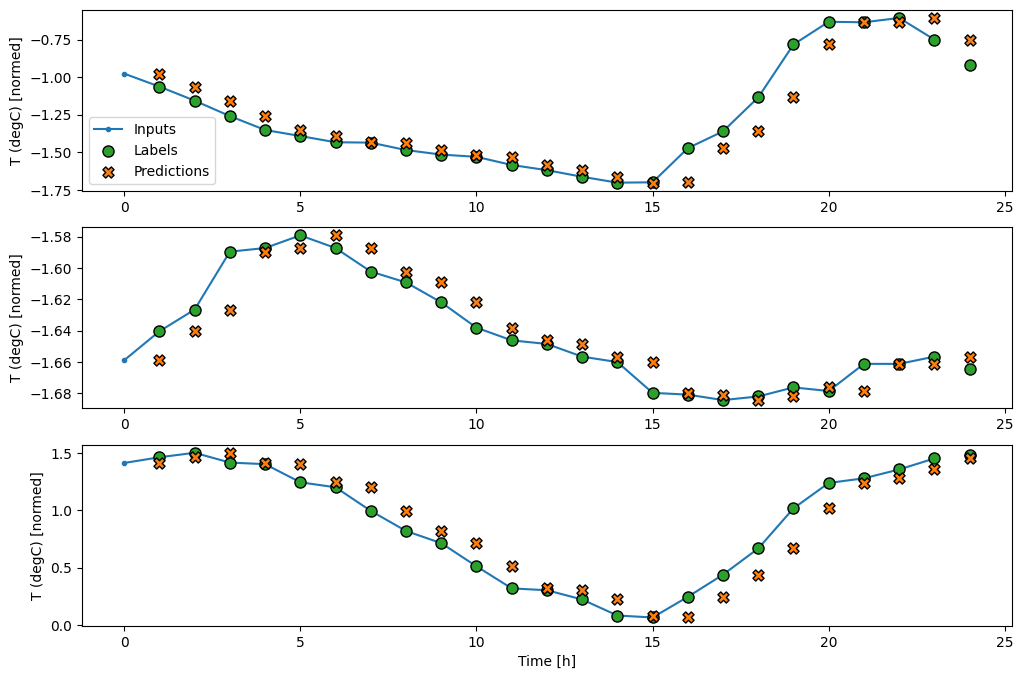

In [ ]:
wide_window.plot(baseline)

### LSTM Model

Predicts 1 timestep into the future but configured with ``return_sequence=True`` so that it can be trained on multiple timesteps simultaneously

Flow of code for LSTM Model is
1. Prepare LSTM model
2. create WindowGenerator object to handle data flow
3. Define training procedute
4. Train
5. Evaluate

In [ ]:
# Prepare LSTM model with 32 units followed by a Dense layer with 1 node
# increase the number of nodes in Dense layer to match number of predict feature
# Not sure if 32 LSTM units is appropriate, tune this param
lstm_model = tf.keras.models.Sequential([
    # Shape [batch, time, features] => [batch, time, lstm_units]
    tf.keras.layers.LSTM(32, return_sequences=True),
    # Shape => [batch, time, features]
    tf.keras.layers.Dense(units=1)
])

In [ ]:
# Preparing WindowGenerator to handle data
wide_window = WindowGenerator(
    input_width=24, label_width=24, shift=1,
    label_columns=['T (degC)'])

wide_window

Total window size: 25
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Label column name(s): ['T (degC)']

In [ ]:
wide_window.train

<_MapDataset element_spec=(TensorSpec(shape=(None, 24, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24, 1), dtype=tf.float32, name=None))>

In [ ]:
MAX_EPOCHS = 20
# packaging training procedure into a function
def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [ ]:
print('Input shape:', wide_window.example[0].shape)
print('Output shape:', lstm_model(wide_window.example[0]).shape)

Input shape: (32, 24, 15)
Output shape: (32, 24, 1)


In [ ]:
# Train model
history = compile_and_fit(lstm_model, wide_window)

IPython.display.clear_output()
val_performance['LSTM'] = lstm_model.evaluate(wide_window.val, return_dict=True)
performance['LSTM'] = lstm_model.evaluate(wide_window.test, verbose=0, return_dict=True)

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0069 - mean_absolute_error: 0.0575


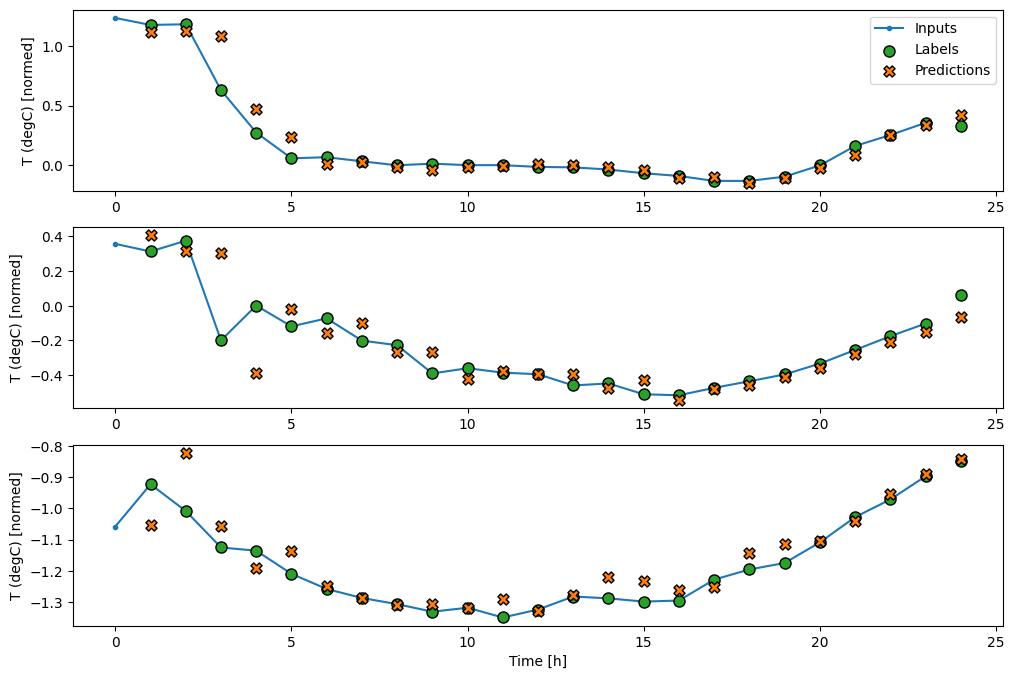

In [ ]:
# Plotting shows predictions for 3 different time slices
wide_window.plot(lstm_model)

### Autoregressive LSTM Model

Flow of code for Autoregressive LSTM Model is
1. Prepare LSTM model
2. create WindowGenerator object to handle data flow
3. Define training procedute
4. Train
5. Evaluate

In [ ]:
# for autoregressive
class FeedBack(tf.keras.Model):
    def __init__(self, units, out_steps):
        super().__init__()
        self.out_steps = out_steps
        self.units = units
        self.lstm_cell = tf.keras.layers.LSTMCell(units)
        # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
        self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
        self.dense = tf.keras.layers.Dense(num_features)
    def warmup(self, inputs):
        # inputs.shape => (batch, time, features)
        # x.shape => (batch, lstm_units)
        x, *state = self.lstm_rnn(inputs)

        # predictions.shape => (batch, features)
        prediction = self.dense(x)
        return prediction, state
    def call(self, inputs, training=None):
        # Use a TensorArray to capture dynamically unrolled outputs.
        predictions = []
        # Initialize the LSTM state.
        prediction, state = self.warmup(inputs)

        # Insert the first prediction.
        predictions.append(prediction)

        # Run the rest of the prediction steps.
        for n in range(1, self.out_steps):
            # Use the last prediction as input.
            x = prediction
            # Execute one lstm step.
            x, state = self.lstm_cell(x, states=state,
                                    training=training)
            # Convert the lstm output to a prediction.
            prediction = self.dense(x)
            # Add the prediction to the output.
            predictions.append(prediction)

        # predictions.shape => (time, batch, features)
        predictions = tf.stack(predictions)
        # predictions.shape => (batch, time, features)
        predictions = tf.transpose(predictions, [1, 0, 2])
        return predictions

In [ ]:
MAX_EPOCHS = 20
# packaging training procedure into a function
def compile_and_fit(model, window, patience=2):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=MAX_EPOCHS,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

In [ ]:
# Preparing WindowGenerator
OUT_STEPS = 24
multi_window = WindowGenerator(input_width=24,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS)

In [ ]:
# Calling autogressive mocel
feedback_model = FeedBack(units=32, out_steps=OUT_STEPS)

In [ ]:
prediction, state = feedback_model.warmup(multi_window.example[0])
prediction.shape

TensorShape([32, 15])

In [ ]:
# test output
print('Output shape (batch, time, features): ', feedback_model(multi_window.example[0]).shape)

Output shape (batch, time, features):  (32, 24, 15)


In [ ]:
import IPython
import IPython.display

437/437 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2932 - mean_absolute_error: 0.3662


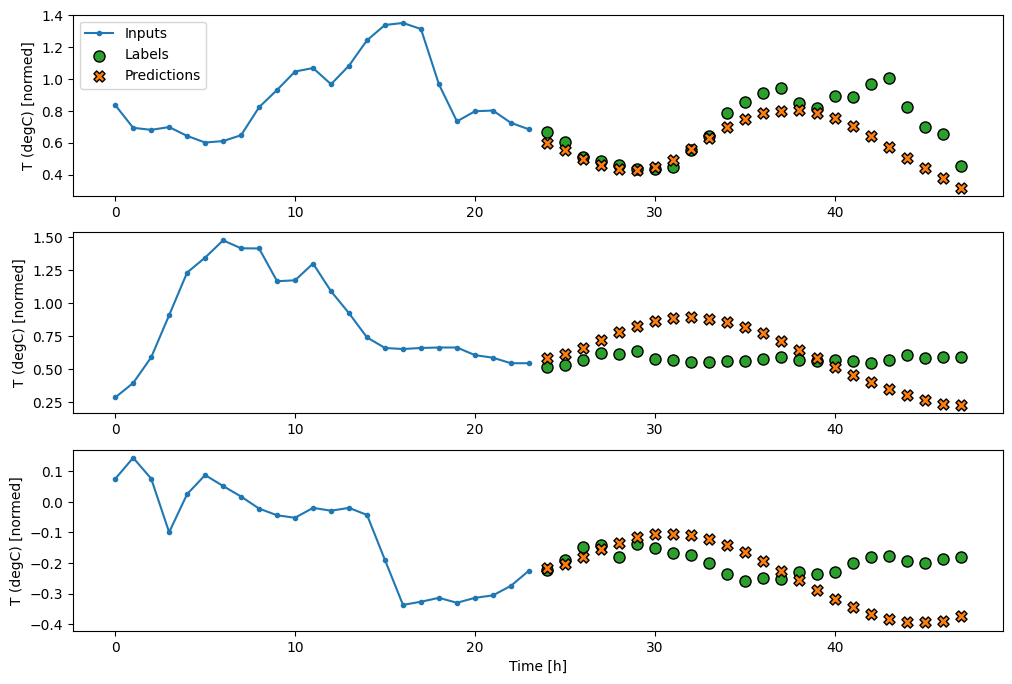

In [ ]:
# then to train
history = compile_and_fit(feedback_model, multi_window)

IPython.display.clear_output()

val_performance = feedback_model.evaluate(multi_window.val, return_dict=True)
test_performance = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)